# NLP Lab 5 · EDA & Cleaning Template — Text Classification

This Colab-ready notebook provides **EDA + cleaning boilerplate** for text classification datasets.

It supports popular Hugging Face datasets (e.g., `imdb`, `ag_news`) and shows how to:
1) Load data
2) Inspect & clean (missing, duplicates, weird characters)
3) Tokenize examples (HF tokenizer)
4) Split with stratification
5) Plot basic EDA (text lengths, class distribution)
6) Word cloud / top-N token frequency

**Instructions**
- Set the `DATASET_NAME` and options in the next cell.
- Run cells in order.


Run in the following Code cell any install you need

In [ ]:

#@title Setup: install libraries (Colab will take ~1–2 minutes)
# If running in Colab, uncomment the next lines.
!pip -q install datasets transformers wordcloud matplotlib scikit-learn numpy pandas unidecode

import pandas as pd
import numpy as np
import re, unicodedata
from collections import Counter
from unidecode import unidecode
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer

plt.rcParams.update({"figure.figsize": (7,4)})  # modest size


## 1) Configuration

In [ ]:

# Choose a dataset available on the Hugging Face Hub.
# Recommended: 'imdb' (binary) or 'ag_news' (4-class).
DATASET_NAME = "Kanakmi/mental-disorders" # @param ["imdb","ag_news","Kanakmi/mental-disorders"]
SAMPLE_FRACTION = 1.0  #@param {type:"number"}
TEXT_COLUMN = "text" # @param {"type":"string"}
LABEL_COLUMN = "label" # @param {"type":"integer"}
RANDOM_SEED = 42        #@param {type:"integer"}

# Optional: choose a tokenizer checkpoint for tokenization examples
TOKENIZER_CHECKPOINT = "distilbert-base-uncased"  #@param {type:"string"}

np.random.seed(RANDOM_SEED)


## 2) Load dataset

In [ ]:

def load_text_classification_dataset(name: str):
    if name == "Kanakmi/mental-disorders":
        ds = load_dataset("Kanakmi/mental-disorders")
        text_col, label_col = "text", "label"
        label_names = [0, 1, 2, 3, 4, 5]

        """
        Labels:
        0:'BPD'
        1:'bipolar'
        2:'depression'
        3:'Anxiety'
        4:'schizophrenia'
        5:'mentalillness'
        """
    else:
        raise ValueError("Unsupported dataset name for this template.")
    return ds, text_col, label_col, label_names

ds, default_text_col, default_label_col, label_names = load_text_classification_dataset(DATASET_NAME)

if TEXT_COLUMN is None: TEXT_COLUMN = default_text_col
if LABEL_COLUMN is None: LABEL_COLUMN = default_label_col

print(ds)
print("Text column:", TEXT_COLUMN, "| Label column:", LABEL_COLUMN)
print("Label names:", label_names)


Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 465051
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 23190
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 92976
    })
})
Text column: text | Label column: label
Label names: [0, 1, 2, 3, 4, 5]


## 3) Optional: downsample for quick experimentation

In [ ]:

def maybe_sample(dataset, frac: float, seed: int = 42):
    if frac >= 1.0:
        return dataset
    n = int(len(dataset) * frac)
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(dataset), size=n, replace=False)
    return dataset.select(list(idx))

if isinstance(ds, DatasetDict):
    ds_sampled = DatasetDict({split: maybe_sample(ds[split], SAMPLE_FRACTION, RANDOM_SEED)
                              for split in ds.keys()})
else:
    ds_sampled = maybe_sample(ds, SAMPLE_FRACTION, RANDOM_SEED)

ds = ds_sampled
print(ds)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 465051
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 23190
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 92976
    })
})


## 4) Convert to pandas for inspection

In [ ]:

def to_pandas(ds_dict, split: str) -> pd.DataFrame:
    if split not in ds_dict:
        raise KeyError(f"Split '{split}' not found. Available: {list(ds_dict.keys())}")
    return ds_dict[split].to_pandas()

train_df = to_pandas(ds, "train")
print(train_df.head(3))


                                                text  label
0  My father - all of my life - has shifted betwe...      0
1  I have health anxiety where I go to the doctor...      3
2  I was thinking about the differences between B...      0


## 5) Inspect raw text (missing, duplicates, weird chars)

In [ ]:

def detect_weird_characters(s: str) -> bool:
    if not isinstance(s, str):
        return False
    for ch in s:
        cat = unicodedata.category(ch)
        if cat.startswith("C") and ch not in ["\n", "\t", "\r"]:
            return True
    return False

missing_text = train_df[TEXT_COLUMN].isna().sum()
missing_label = train_df[LABEL_COLUMN].isna().sum()
dup_rows = train_df.duplicated(subset=[TEXT_COLUMN, LABEL_COLUMN]).sum()
weird_flags = train_df[TEXT_COLUMN].astype(str).apply(detect_weird_characters)
weird_count = weird_flags.sum()

print(f"Missing text: {missing_text}")
print(f"Missing labels: {missing_label}")
print(f"Duplicate rows (text+label): {dup_rows}")
print(f"Rows with control/non-printable chars: {weird_count}")


Missing text: 0
Missing labels: 0
Duplicate rows (text+label): 11780
Rows with control/non-printable chars: 957


### Cleaning helpers

In [ ]:

import re, os, unicodedata

URL_RE = re.compile(r"https?://\S+|www\.\S+")
HTML_TAG_RE = re.compile(r"<.*?>")

def basic_clean(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = text.strip()
    t = re.sub(URL_RE, " ", t)
    t = re.sub(HTML_TAG_RE, " ", t)
    t = unicodedata.normalize("NFKC", t)
    t = re.sub(r"\s+", " ", t)
    return t

def remove_duplicates_and_missing(df: pd.DataFrame, text_col: str, label_col: str) -> pd.DataFrame:
    df2 = df.dropna(subset=[text_col, label_col]).copy()
    before = len(df2)
    df2[text_col] = df2[text_col].astype(str).apply(basic_clean)
    df2 = df2.drop_duplicates(subset=[text_col, label_col])
    after = len(df2)
    print(f"Removed {before - after} duplicates/missing. New size: {after}")
    return df2

clean_train_df = remove_duplicates_and_missing(train_df, TEXT_COLUMN, LABEL_COLUMN)
clean_train_df.head(3)


Removed 12659 duplicates/missing. New size: 452392


,text,label
0,My father - all of my life - has shifted betwe...,0
1,I have health anxiety where I go to the doctor...,3
2,I was thinking about the differences between B...,0


## 6) Tokenization examples (Hugging Face)

In [ ]:

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_CHECKPOINT)

sample_texts = clean_train_df[TEXT_COLUMN].sample(3, random_state=RANDOM_SEED).tolist()
enc = tokenizer(sample_texts, truncation=True, padding=False, return_tensors=None)
for i, t in enumerate(sample_texts):
    print(f"--- Sample {i+1} ---")
    print(t[:300], "..." if len(t)>300 else "")
    print("Tokens:", tokenizer.convert_ids_to_tokens(enc['input_ids'][i][:20]))


--- Sample 1 ---
Just wondering if these medications work for bpd. My doctor said that these won't work and that normally you would spiral from them if you have bpd. He said behaviour therapy is the best thing for bpd, is this true or false? 
Tokens: ['[CLS]', 'just', 'wondering', 'if', 'these', 'medications', 'work', 'for', 'bp', '##d', '.', 'my', 'doctor', 'said', 'that', 'these', 'won', "'", 't', 'work']
--- Sample 2 ---
Dae do something stupid because your emotions are so everywhere but empty at the same time? Like currently contemplating going to a bar by myself. It’s dark out and I’m a female. Smart idea? No. Might do it anyways. 
Tokens: ['[CLS]', 'da', '##e', 'do', 'something', 'stupid', 'because', 'your', 'emotions', 'are', 'so', 'everywhere', 'but', 'empty', 'at', 'the', 'same', 'time', '?', 'like']
--- Sample 3 ---
So my best friend has been leaving me on seen, even when I was opening up to her about rough things I’m going through. I’ve always been there for her when she nee

## 7) Split with stratification

In [ ]:

from sklearn.model_selection import train_test_split

y = clean_train_df[LABEL_COLUMN].values
X = clean_train_df[[TEXT_COLUMN, LABEL_COLUMN]].copy()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("Sizes:", len(X_train), len(X_val), len(X_test))


Sizes: 316674 67859 67859


## 8) EDA Plots

Train length histogram


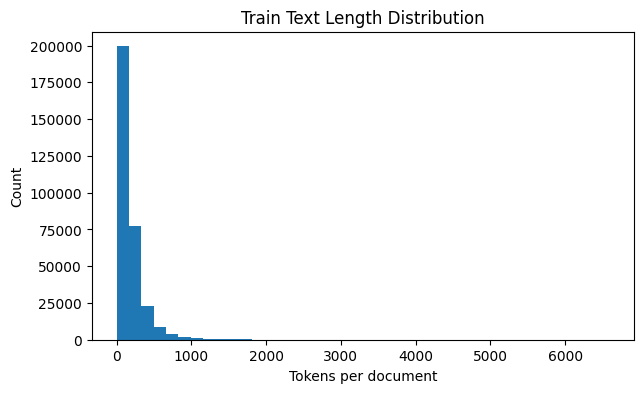

Train class distribution


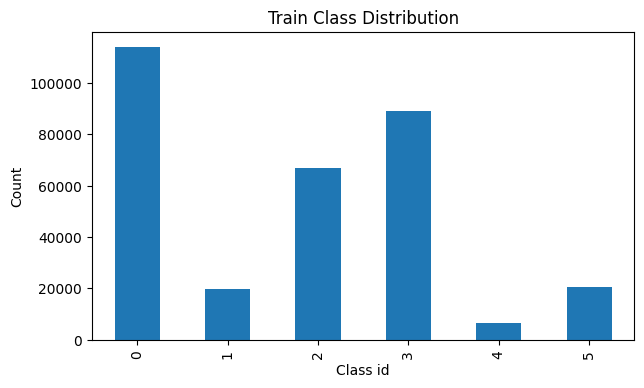

In [ ]:

import matplotlib.pyplot as plt

def plot_text_length_hist(df: pd.DataFrame, text_col: str, title: str):
    lengths = df[text_col].astype(str).apply(lambda x: len(x.split()))
    plt.figure()
    plt.hist(lengths, bins=40)
    plt.title(title)
    plt.xlabel("Tokens per document")
    plt.ylabel("Count")
    plt.show()

def plot_class_distribution(df: pd.DataFrame, label_col: str, title: str):
    counts = df[label_col].value_counts().sort_index()
    plt.figure()
    counts.plot(kind="bar")
    plt.title(title)
    plt.xlabel("Class id")
    plt.ylabel("Count")
    plt.show()

print("Train length histogram")
plot_text_length_hist(X_train, TEXT_COLUMN, "Train Text Length Distribution")

print("Train class distribution")
plot_class_distribution(X_train, LABEL_COLUMN, "Train Class Distribution")


## 9) Frequent tokens & Word Cloud (optional)

In [ ]:

from collections import Counter

def tokenize_simple(text: str) -> list:
    return re.findall(r"\b\w+\b", text.lower())

def top_n_tokens(df: pd.DataFrame, text_col: str, n: int = 25) -> list:
    counter = Counter()
    for t in df[text_col].astype(str).tolist():
        counter.update(tokenize_simple(t))
    return counter.most_common(n)

top_25 = top_n_tokens(X_train, TEXT_COLUMN, n=25)
print("Top 25 tokens:", top_25)


Top 25 tokens: [('i', 4108347), ('and', 1860428), ('to', 1809401), ('the', 1175472), ('my', 1115160), ('a', 1099308), ('it', 979369), ('of', 804555), ('me', 776108), ('t', 730253), ('that', 711503), ('in', 596757), ('but', 581098), ('m', 562762), ('for', 518519), ('have', 495316), ('is', 489257), ('this', 475667), ('with', 469579), ('so', 444109), ('was', 443783), ('just', 438255), ('s', 425188), ('like', 416729), ('feel', 328537)]


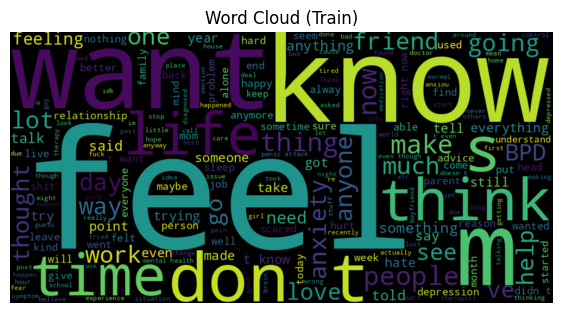

In [ ]:

# Word cloud (optional)
from wordcloud import WordCloud
text_all = " ".join(X_train[TEXT_COLUMN].astype(str).tolist())
wc = WordCloud(width=1000, height=500).generate(text_all)
plt.figure()
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud (Train)")
plt.show()


## 10) Save cleaned splits

In [ ]:

import os
output_dir = "cleaned_splits"
os.makedirs(output_dir, exist_ok=True)

X_train.to_csv(os.path.join(output_dir, "train.csv"), index=False)
X_val.to_csv(os.path.join(output_dir, "val.csv"), index=False)
X_test.to_csv(os.path.join(output_dir, "test.csv"), index=False)

print("Saved to:", output_dir)


Saved to: cleaned_splits
